In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2
import numpy as np
import scipy as sp
import pandas as pd
import networkx as nx
import random
import matplotlib.pyplot as plt
# import warnings filter
from warnings import simplefilter
# ignore all future warnings
simplefilter(action='ignore', category=FutureWarning)
from IPython.core.display import HTML
HTML('<style>.container { width:95% !important; }</style><style>.output_png {display: table-cell;text-align: center;vertical-align: middle;}</style>')

In [2]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version built with PyTorch: {torch.version.cuda}")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"Current GPU name: {torch.cuda.get_device_name(torch.cuda.current_device())}")
else:
    print("PyTorch was not built with CUDA support or CUDA is not configured correctly.")


PyTorch version: 2.2.2
CUDA available: False
PyTorch was not built with CUDA support or CUDA is not configured correctly.


In [3]:
import warnings
warnings.filterwarnings("ignore", message=".*PossibleUserWarning.*")
warnings.filterwarnings("ignore", message=".*does not have many workers.*")
warnings.filterwarnings("ignore", message=".*to enable TensorBoard support.*")

import os, sys
sys.stderr = open(os.devnull, 'w')

In [4]:
import sys
from pathlib import Path
from pathlib import Path

_cwd = Path().resolve()
_candidates = (_cwd, _cwd.parent)
for _root in _candidates:
    if (_root / 'eqm_decompositional_graph_generator').exists():
        if str(_root) not in sys.path:
            sys.path.insert(0, str(_root))
        break
else:
    raise ModuleNotFoundError("Could not locate 'eqm_decompositional_graph_generator' package; adjust sys.path.")

del _cwd, _candidates, _root


# Code

In [5]:
# Shared notebook helpers (kept in a .py module to keep notebooks lean)
try:
    from notebooks.notebook_utils import (
        offset_neg_graphs,
        plot_sample,
        select_pos_neg,
        plot_networkx_graphs,
        show_samples,
        graph_label_histogram,
        summarize_label_histogram_alignment,
        plot_label_histogram_alignment,
        fit_graph_generator,
        run_label_histogram_analysis,
        compare_real_vs_generated,
    )
except ModuleNotFoundError:
    from notebook_utils import (
        offset_neg_graphs,
        plot_sample,
        select_pos_neg,
        plot_networkx_graphs,
        show_samples,
        graph_label_histogram,
        summarize_label_histogram_alignment,
        plot_label_histogram_alignment,
        fit_graph_generator,
        run_label_histogram_analysis,
        compare_real_vs_generated,
    )


---

# Data

In [11]:
DATASET_TYPE = 'MOLECULAR'

In [12]:
DATASET_TYPE = 'ARTIFICIAL'  # Uncomment to use the synthetic dataset instead.

In [13]:
from functools import partial

try:
    from notebooks.demo_pipeline_utils import build_dataset as _build_dataset
except ModuleNotFoundError:
    from demo_pipeline_utils import build_dataset as _build_dataset

# Dataset builder bound to notebook dataset type
build_dataset = partial(_build_dataset, dataset_type=DATASET_TYPE)


---

# Experiment

In [14]:
import sys

from sklearn.model_selection import train_test_split

try:
    from NSPPK.nsppk import NSPPK, NodeNSPPK
except ModuleNotFoundError:
    from nsppk import NSPPK, NodeNSPPK
from AbstractGraph.abstract_graph_operators import compose, cycle, neighborhood, unlabel
from AbstractGraph.feasibility import (
    FeasibilityEstimator,
    FeasibilityEstimatorFeatureCannotExist,
    WithinRangeFeasibilityEstimatorFromNumericalFunction,
)
from eqm_decompositional_graph_generator.node_engine import EqMDecompositionalNodeGenerator
from eqm_decompositional_graph_generator.graph_engine import (
    EqMDecompositionalGraphDecoder,
    EqMDecompositionalGraphGenerator,
)
from notebooks.notebook_utils import sample_positive_endpoint_pair

try:
    from notebooks.notebook_utils import fit_graph_generator, run_label_histogram_analysis, compare_real_vs_generated
except ModuleNotFoundError:
    from notebook_utils import fit_graph_generator, run_label_histogram_analysis, compare_real_vs_generated

REPO_ROOT = next(
    candidate.resolve()
    for candidate in [Path.cwd(), Path.cwd().parent]
    if (candidate / 'eqm_decompositional_graph_generator').exists()
)
ARTIFACT_ROOT = REPO_ROOT / '.artifacts'
CHECKPOINT_ROOT = ARTIFACT_ROOT / 'checkpoints' / 'eqm'


try:
    from notebooks.demo_pipeline_utils import prepare_experiment, build_graph_generator
except ModuleNotFoundError:
    from demo_pipeline_utils import prepare_experiment, build_graph_generator


---

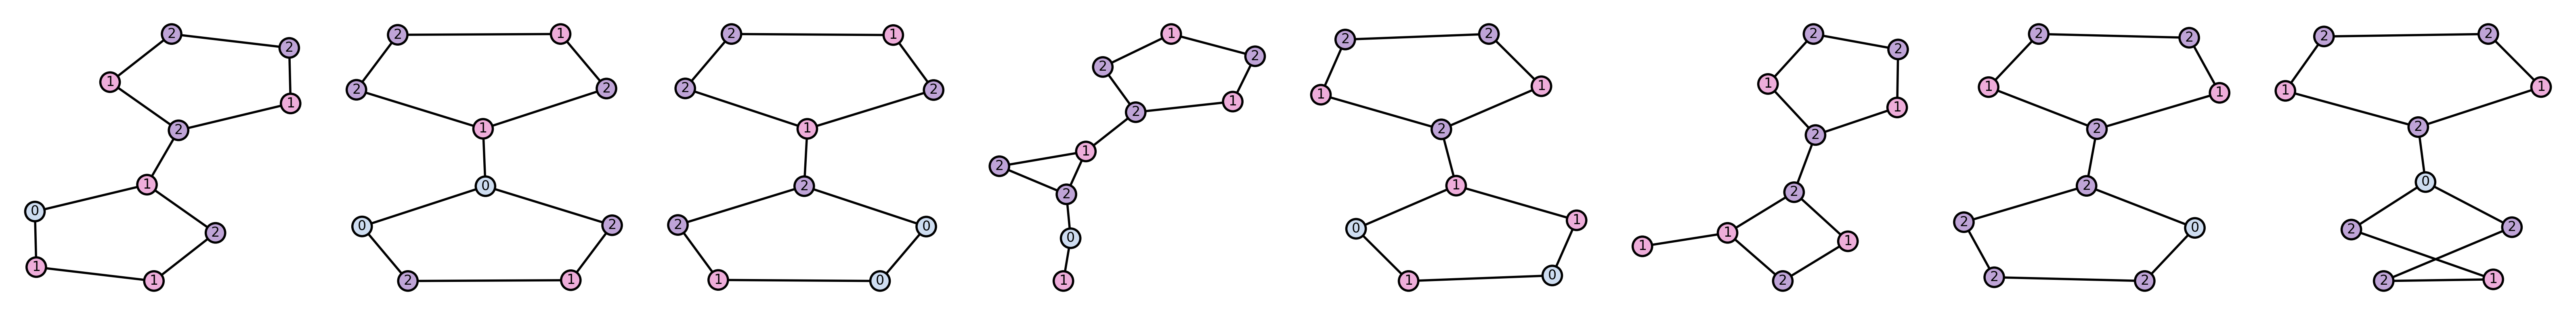

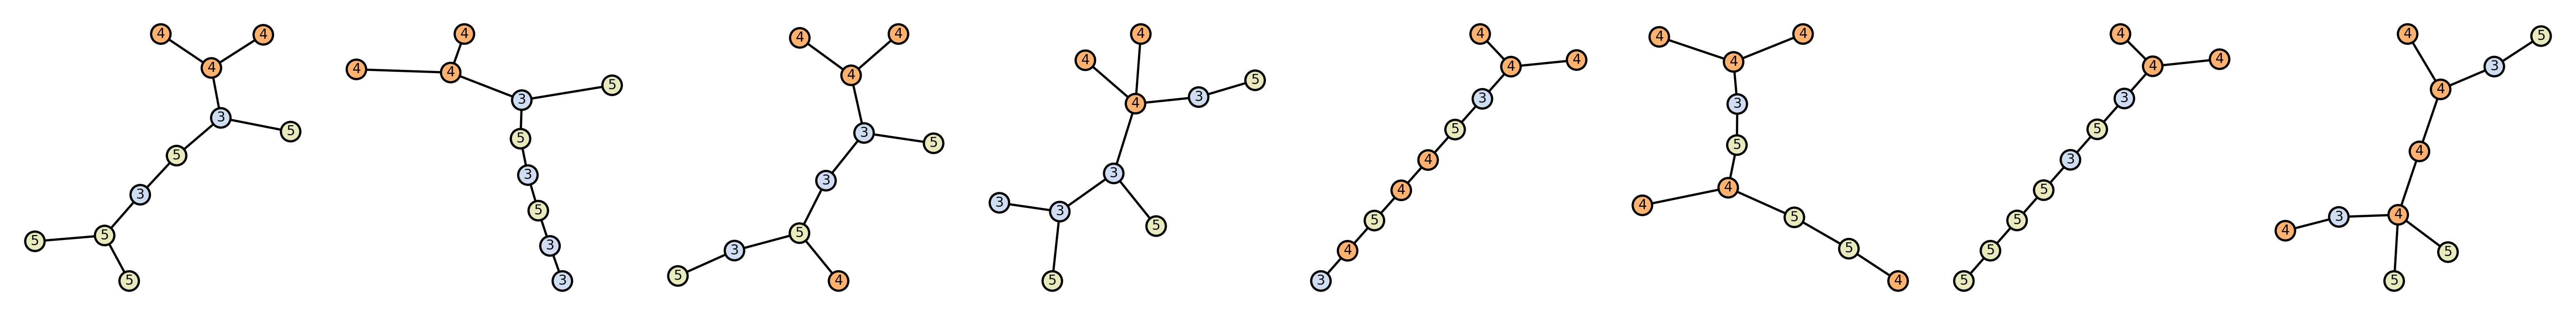

train_graphs:188   test_graphs:10


In [15]:
graphs, targets, train_graphs, test_graphs, train_targets, test_targets = prepare_experiment(
    build_dataset_fn=build_dataset,
    dataset_size=200,
    test_size=10,
    random_state=42,
)

graph_generator = build_graph_generator(
    # General
    verbose=2,
    nbits=12,
    # Vectorizers
    node_vectorizer_radius=2,
    node_vectorizer_distance=4,
    node_vectorizer_connector=1,
    node_vectorizer_nbits=12,
    node_vectorizer_dense=True,
    node_vectorizer_parallel=True,
    node_vectorizer_use_edges_as_features=True,
    graph_vectorizer_radius=2,
    graph_vectorizer_distance=4,
    graph_vectorizer_connector=1,
    graph_vectorizer_nbits=12,
    graph_vectorizer_dense=True,
    graph_vectorizer_parallel=True,
    graph_vectorizer_use_edges_as_features=True,
    # Feasibility
    feasibility_size_quantile=None,
    feasibility_unlabeled_radius=2,
    feasibility_valence_radius=1,
    feasibility_unlabeled_nbits=19,
    feasibility_valence_nbits=19,
    feasibility_cycle_nbits=19,
    feasibility_parallel=True,
    feasibility_backend="dill",
    # Network architecture
    latent_embedding_dimension=128,
    number_of_transformer_layers=4,
    transformer_attention_head_count=4,
    transformer_dropout=0.2,
    # Training
    learning_rate=1e-4,
    maximum_epochs=250,
    batch_size=16,
    total_steps=100,
    verbose_epoch_interval=10,
    enable_early_stopping=True,
    early_stopping_monitor="val_total",
    early_stopping_mode="min",
    early_stopping_patience=20,
    early_stopping_min_delta=100.0,
    early_stopping_ema_alpha=0.3,
    restore_best_checkpoint=True,
    important_feature_index=1,
    # Loss weights
    lambda_degree_importance=5e3,
    default_exist_pos_weight=1.0,
    lambda_node_exist_importance=0,
    lambda_node_count_importance=0.0,
    lambda_node_label_importance=5e4,
    lambda_edge_label_importance=5e3,
    lambda_locality_importance=1e4,
    lambda_direct_edge_importance=1e4,
    lambda_edge_count_importance=0.0,
    lambda_degree_edge_consistency_importance=0.0,
    lambda_auxiliary_locality_importance=1.0,
    lambda_auxiliary_edge_importance=1.0,
    # Sampling and guidance
    degree_temperature=1,
    pool_condition_tokens=False,
    eqm_sigma=0.2,
    sampling_step_size=0.05,
    sampling_steps=None,
    langevin_noise_scale=0.0,
    cfg_condition_dropout_prob=0.1,
    cfg_null_target_strategy="zero",
    target_classification_max_distinct=20,
    # Locality supervision and generation
    locality_horizon=1,
    locality_sample_fraction=0.5,
    negative_sample_factor=1,
    locality_sampling_strategy="stratified_preserve",
    locality_target_positive_ratio=0.5,
    use_feasibility_filtering=True,
    max_feasibility_attempts=20,
    feasibility_candidates_per_attempt=8,
    feasibility_failure_mode="return_partial",
    # Decoder
    decoder_existence_threshold=0.5,
    decoder_enforce_connectivity=True,
    decoder_degree_slack_penalty=1e6,
    decoder_warm_start_mst=True,
    decoder_n_jobs=1,
    # Outputs
    artifact_root=ARTIFACT_ROOT,
    checkpoint_root=CHECKPOINT_ROOT,
)


Fitting model on 188 graphs
Fitting feasibility estimator on 188 graphs
Supervision plan:
  node_labels: mode=learned, enabled. 6 node labels detected.
  edge_labels: mode=constant, enabled. All labelled edges share one label.
  direct_edges: mode=learned, enabled, horizon=1. Generator should learn horizon-1 edge presence for the decoder.
  auxiliary_locality: mode=disabled, disabled. No auxiliary locality is needed when locality_horizon=1.
adj_mtx_to_targets[direct_edge, horizon=1]: sampling 11181 pairs (50.00%) from 22362 total pairs (pos=7532, neg=14830, negative_sample_factor=1, sampling_strategy=stratified_preserve, target_positive_ratio=0.500).
adj_mtx_to_targets[direct_edge, horizon=1]: using pos=3766, neg=7415, positive_ratio=0.337.
Training conditional model on 188 graphs with up to 10 nodes each.
Using direct-edge supervision with 11181 labelled pairs.
Existence supervision disabled: all training graphs have the same node count and the valid existence target is constant.
Dire

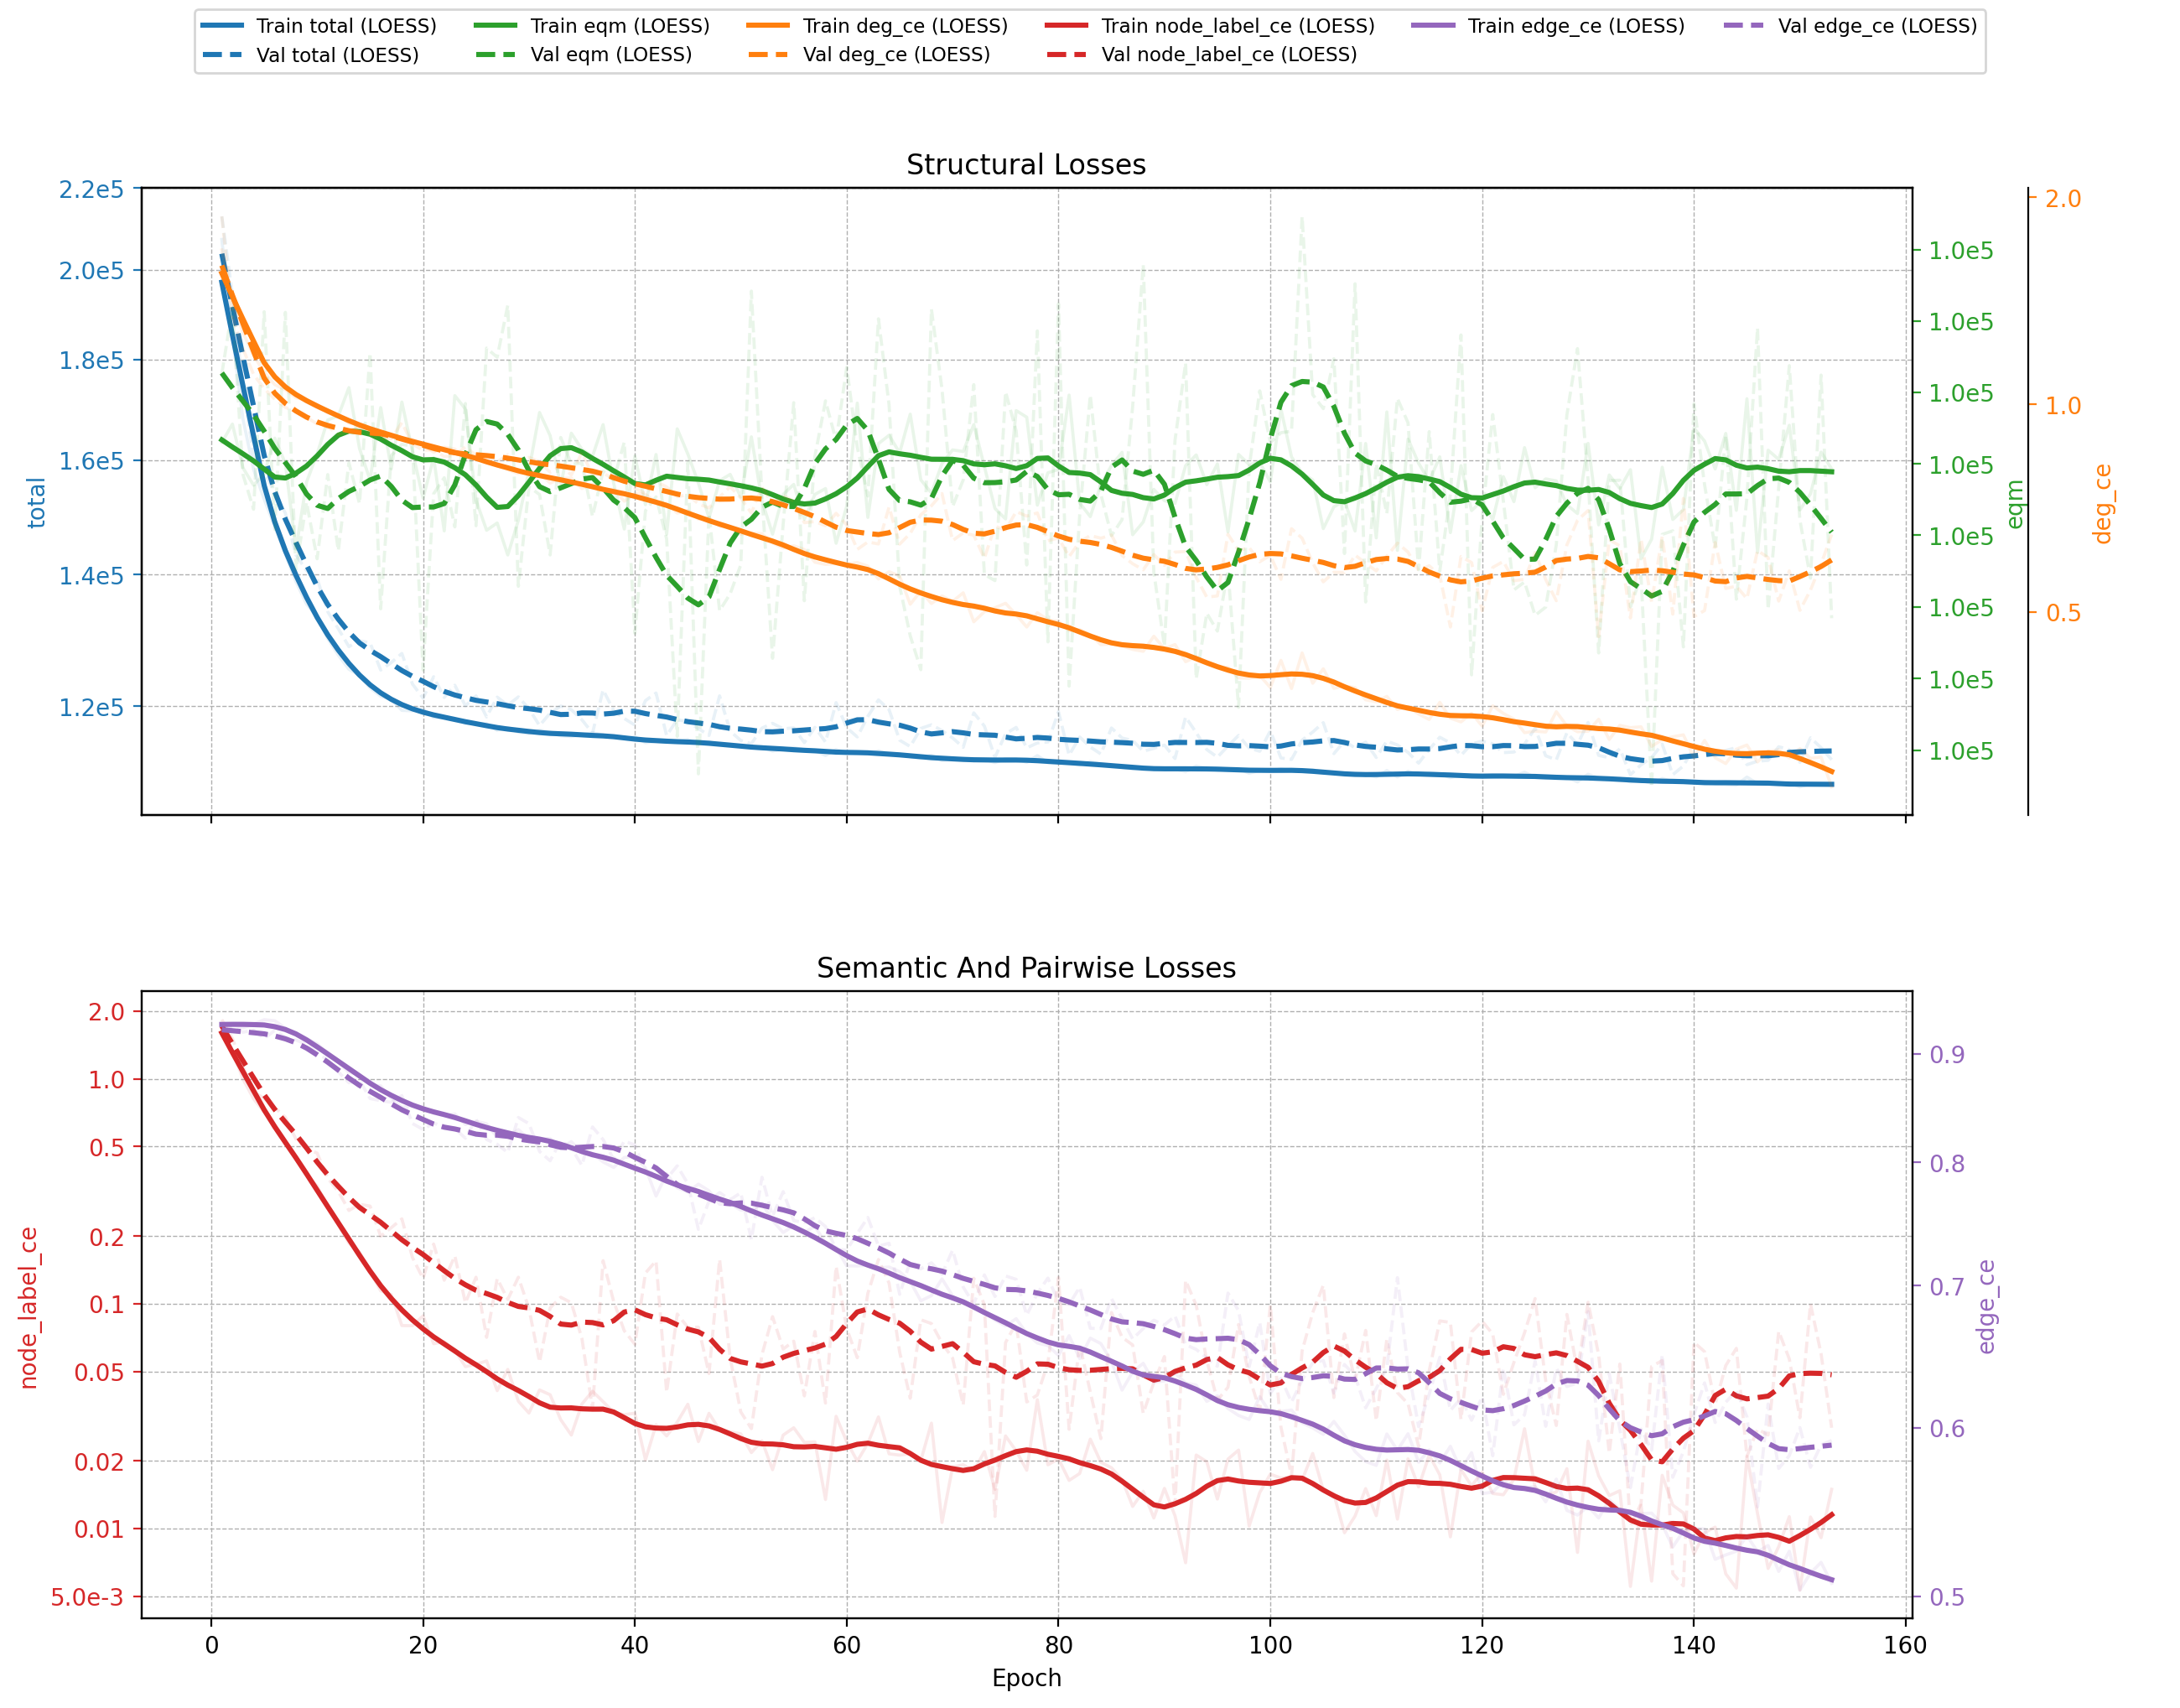

Restored best checkpoint: best_epoch=133, val_total=110786.2891, raw_val_eqm=102377.1875, stopped_epoch=154
  path=/Users/fabriziocosta/Resilio Sync/Sync/Projects/GraphGen/.artifacts/checkpoints/eqm/EqMDecompositionalNodeGenerator_eb44678ac3f344a19fd101a9b5a70d91/best-132-110786.2891.ckpt
CPU times: user 1h 9min 57s, sys: 6min 15s, total: 1h 16min 12s
Wall time: 11min 2s


In [16]:
%%time
graph_generator = fit_graph_generator(graph_generator, train_graphs)


## Conditioning vs Generated Label Histograms

In [ ]:
label_histogram_summary = run_label_histogram_analysis(graph_generator, train_graphs, n_compare=5)


In [ ]:
show_samples(n_samples=7, graphs=train_graphs, targets=train_targets, graph_generator=graph_generator)

In [ ]:
show_samples(n_samples=7, graphs=test_graphs, targets=test_targets, graph_generator=graph_generator)

## Positive-to-Positive Conditioning Interpolation

Select two positive training graphs at random, interpolate between them, and display the endpoints plus feasible generated graphs.

In [ ]:
selected_indices, selected_targets, endpoint_graph_a, endpoint_graph_b = sample_positive_endpoint_pair(
    train_graphs,
    train_targets,
)
print("Endpoint indices:", selected_indices)
print("Endpoint targets:", selected_targets)

display_mode = 'molecule' if DATASET_TYPE == 'MOLECULAR' else 'not_molecule'
print("Selected endpoint graphs:")
plot_networkx_graphs([endpoint_graph_a, endpoint_graph_b], n_cols=2, mode=display_mode)

interpolation_result = graph_generator.interpolate(
    endpoint_graph_a,
    endpoint_graph_b,
    k=3,
    apply_feasibility_filtering=True,
)
display(interpolation_result["summary"])

missing_steps = interpolation_result["summary"].loc[
    ~interpolation_result["summary"]["decoded"],
    "step",
].tolist()
if missing_steps:
    print("Interpolation steps rejected by feasibility filtering:", missing_steps)

graphs_to_display = [endpoint_graph_a, *interpolation_result["generated_graphs"], endpoint_graph_b]
print("Endpoints and generated interpolation graphs:")
plot_networkx_graphs(graphs_to_display, n_cols=max(1, len(graphs_to_display)), mode=display_mode)


## Real vs Generated Distribution Comparison

In [ ]:
distribution_comparison = compare_real_vs_generated(
    graph_generator,
    test_graphs,
    apply_feasibility_filtering=True,
)


---